In [6]:
import json
import numpy as np
import pandas as pd
import scanpy as sc

from pathlib import Path
from PIL import Image


# Find project root
current_path = Path.cwd()

if (current_path / "data" / "processed").exists():
    PROJECT_ROOT = current_path
elif (current_path.parent / "data" / "processed").exists():
    PROJECT_ROOT = current_path.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_ROOT = PROJECT_ROOT / "data" / "processed"

SAMPLE_IDS = [
    "AD_1_LS",
    "AD_2_LS",
    "AD_3_LS",
    "AD_4_LS"
]

datasets = {}

for sample_id in SAMPLE_IDS:

    print(f"Loading {sample_id}...")

    sample_path = DATA_ROOT / sample_id / sample_id
    spatial_path = sample_path / "spatial"

    # Load gene-expression matrix
    h5_path = sample_path / "filtered_feature_bc_matrix.h5"

    adata = sc.read_10x_h5(h5_path, genome=None)
    adata.var_names_make_unique()

    # Load spatial coordinates
    positions_path = spatial_path / "tissue_positions_list.csv"

    positions = pd.read_csv(
        positions_path,
        header=None,
        names=[
            "barcode",
            "in_tissue",
            "array_row",
            "array_col",
            "pixel_row",
            "pixel_col"
        ]
    )

    positions = positions.set_index("barcode")

    # Keep only barcodes present in both files
    common_barcodes = adata.obs_names.intersection(positions.index)

    adata = adata[common_barcodes].copy()
    positions = positions.loc[common_barcodes]

    # Add spatial information
    for column in positions.columns:
        adata.obs[column] = positions[column].values

    adata.obs["sample_id"] = sample_id
    adata.obs["condition"] = "AD_lesional"

    # Load H&E image
    image_path = spatial_path / "tissue_hires_image.png"
    image = Image.open(image_path).convert("RGB")

    datasets[sample_id] = {
        "adata": adata,
        "image": image,
        "positions": positions
    }

    print(f"  Spots: {adata.n_obs}")
    print(f"  Genes: {adata.n_vars}")
    print(f"  Image size: {image.size}")

print("\nAll datasets loaded successfully!")

Loading AD_1_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  Spots: 188
  Genes: 21587
  Image size: (1924, 2000)
Loading AD_2_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  Spots: 335
  Genes: 21587
  Image size: (2000, 2000)
Loading AD_3_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  Spots: 791
  Genes: 21587
  Image size: (2000, 1992)
Loading AD_4_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  Spots: 1177
  Genes: 21587
  Image size: (2000, 1996)

All datasets loaded successfully!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

# Paths
sample_path = Path(
    "../data/processed/AD_1_LS/AD_1_LS"
)

results_path = Path("../outputs/results")
figures_path = Path("../outputs/figures")

# Load processed spatial data
adata = __import__("scanpy").read_h5ad(
    results_path / "AD_1_LS_processed.h5ad"
)

# Load H&E image
image_path = sample_path / "spatial/tissue_hires_image.png"
img = Image.open(image_path).convert("RGB")

# Load scale factor
import json

with open(sample_path / "spatial/scalefactors_json.json") as f:
    scalefactors = json.load(f)

scale = scalefactors["tissue_hires_scalef"]

print("Image size:", img.size)
print("Dataset shape:", adata.shape)
print("Scale factor:", scale)

Image size: (1924, 2000)
Dataset shape: (188, 21587)
Scale factor: 0.2


In [2]:
from PIL import ImageStat

# Convert image to NumPy array
image_array = np.array(img)

# Spot coordinates in image-resolution pixels
x_coords = (
    adata.obs["pixel_col"].to_numpy() * scale
).astype(int)

y_coords = (
    adata.obs["pixel_row"].to_numpy() * scale
).astype(int)

patch_size = 32
half_patch = patch_size // 2

features = []

for x, y in zip(x_coords, y_coords):

    x1 = max(0, x - half_patch)
    x2 = min(image_array.shape[1], x + half_patch)

    y1 = max(0, y - half_patch)
    y2 = min(image_array.shape[0], y + half_patch)

    patch = image_array[y1:y2, x1:x2]

    mean_rgb = patch.mean(axis=(0, 1))
    std_rgb = patch.std(axis=(0, 1))

    brightness = mean_rgb.mean()

    features.append([
        *mean_rgb,
        *std_rgb,
        brightness
    ])

image_features = pd.DataFrame(
    features,
    columns=[
        "mean_R",
        "mean_G",
        "mean_B",
        "std_R",
        "std_G",
        "std_B",
        "brightness"
    ],
    index=adata.obs_names
)

print(image_features.shape)
print(image_features.head())

(188, 7)
                        mean_R      mean_G      mean_B      std_R      std_G  \
AAAGTGTGATTTATCT-1  201.265625  187.759766  220.932617  30.905124  29.710992   
AAAGTTGACTCCCGTA-1  187.768555  173.896484  214.456055  23.550190  28.657171   
AACACACGCTCGCCGC-1  194.288086  181.853516  219.535156  18.048438  17.324342   
AACCCTACTGTCAATA-1  189.847656  177.244141  214.784180  29.607594  34.639225   
AACCGCTAAGGGATGC-1  223.816406  210.348633  229.889648  18.146417  14.931633   

                        std_B  brightness  
AAAGTGTGATTTATCT-1  12.817390  203.319336  
AAAGTTGACTCCCGTA-1  14.713873  192.040365  
AACACACGCTCGCCGC-1   7.858908  198.558919  
AACCCTACTGTCAATA-1  20.386435  193.958659  
AACCGCTAAGGGATGC-1   8.567433  221.351562  


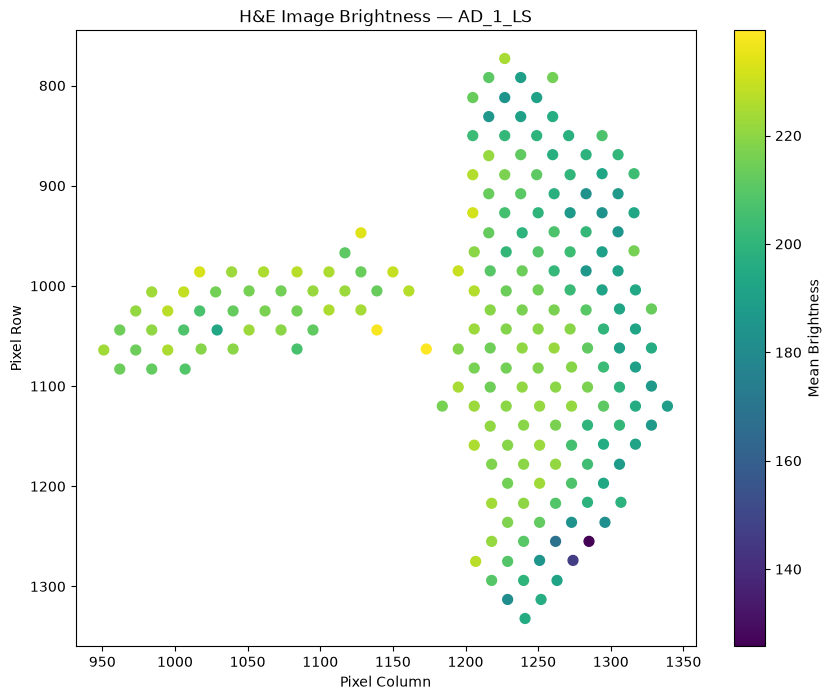

In [3]:
# Visualize mean brightness across spatial spots

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    x_coords,
    y_coords,
    c=image_features["brightness"],
    cmap="viridis",
    s=50
)

plt.gca().invert_yaxis()
plt.colorbar(scatter, label="Mean Brightness")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.title("H&E Image Brightness — AD_1_LS")
plt.show()

In [4]:
# Save extracted image features

image_features.to_csv(
    results_path / "AD_1_LS_image_features.csv"
)

print("Image features saved!")

Image features saved!


In [7]:
import json
import numpy as np
import pandas as pd

from PIL import Image
from pathlib import Path

all_features = []

for sample_id, sample_data in datasets.items():

    print(f"Processing {sample_id}...")

    adata_sample = sample_data["adata"]
    image = sample_data["image"]

    sample_path = (
        DATA_ROOT / sample_id / sample_id
    )

    spatial_path = sample_path / "spatial"

    with open(
        spatial_path / "scalefactors_json.json"
    ) as f:
        scalefactors = json.load(f)

    scale = scalefactors["tissue_hires_scalef"]

    image_array = np.array(image.convert("RGB"))

    x_coords = (
        adata_sample.obs["pixel_col"].to_numpy() * scale
    ).astype(int)

    y_coords = (
        adata_sample.obs["pixel_row"].to_numpy() * scale
    ).astype(int)

    patch_size = 32
    half_patch = patch_size // 2

    features = []

    for x, y in zip(x_coords, y_coords):

        x1 = max(0, x - half_patch)
        x2 = min(image_array.shape[1], x + half_patch)

        y1 = max(0, y - half_patch)
        y2 = min(image_array.shape[0], y + half_patch)

        patch = image_array[y1:y2, x1:x2]

        mean_rgb = patch.mean(axis=(0, 1))
        std_rgb = patch.std(axis=(0, 1))

        brightness = mean_rgb.mean()

        features.append([
            *mean_rgb,
            *std_rgb,
            brightness
        ])

    sample_features = pd.DataFrame(
        features,
        columns=[
            "mean_R",
            "mean_G",
            "mean_B",
            "std_R",
            "std_G",
            "std_B",
            "brightness"
        ],
        index=adata_sample.obs_names
    )

    sample_features["sample_id"] = sample_id

    all_features.append(sample_features)

    print(
        f"Extracted {len(sample_features)} spot features"
    )

combined_features = pd.concat(all_features)

print("\nCombined feature shape:")
print(combined_features.shape)

print("\nFeatures per sample:")
print(combined_features["sample_id"].value_counts())

Processing AD_1_LS...
Extracted 188 spot features
Processing AD_2_LS...
Extracted 335 spot features
Processing AD_3_LS...
Extracted 791 spot features
Processing AD_4_LS...
Extracted 1177 spot features

Combined feature shape:
(2491, 8)

Features per sample:
sample_id
AD_4_LS    1177
AD_3_LS     791
AD_2_LS     335
AD_1_LS     188
Name: count, dtype: int64


In [8]:
# Combine gene expression with image features

TARGET_GENES = [
    "KRT14",
    "KRT5",
    "KRT10",
    "FLG",
    "IL13",
    "IL4"
]

expression_tables = []

for sample_id, sample_data in datasets.items():

    adata_sample = sample_data["adata"]

    # Extract target genes
    available_genes = [
        gene for gene in TARGET_GENES
        if gene in adata_sample.var_names
    ]

    expression = adata_sample[:, available_genes].X

    # Convert sparse matrix to dense array
    if hasattr(expression, "toarray"):
        expression = expression.toarray()

    expression_df = pd.DataFrame(
        expression,
        index=adata_sample.obs_names,
        columns=available_genes
    )

    # Apply log transformation
    expression_df = np.log1p(expression_df)

    expression_df["sample_id"] = sample_id

    expression_tables.append(expression_df)


combined_expression = pd.concat(expression_tables)

# Combine image features and expression
model_table = combined_features.join(
    combined_expression.drop(columns=["sample_id"]),
    how="inner"
)

print("Model table shape:", model_table.shape)
print("\nColumns:")
print(model_table.columns.tolist())

print("\nMissing values:")
print(model_table.isna().sum().sum())

display(model_table.head())

Model table shape: (3791, 14)

Columns:
['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'brightness', 'sample_id', 'KRT14', 'KRT5', 'KRT10', 'FLG', 'IL13', 'IL4']

Missing values:
0


,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness,sample_id,KRT14,KRT5,KRT10,FLG,IL13,IL4
AAAGTGTGATTTATCT-1,201.265625,187.759766,220.932617,30.905124,29.710992,12.817390,203.319336,AD_1_LS,7.100027,6.284134,6.579251,1.386294,0.0,0.0
AAAGTTGACTCCCGTA-1,187.768555,173.896484,214.456055,23.550190,28.657171,14.713873,192.040365,AD_1_LS,6.373320,5.533390,7.857868,3.044523,0.0,0.0
AACACACGCTCGCCGC-1,194.288086,181.853516,219.535156,18.048438,17.324342,7.858908,198.558919,AD_1_LS,6.242223,5.209486,7.534228,1.945910,0.0,0.0
AACCCTACTGTCAATA-1,189.847656,177.244141,214.784180,29.607594,34.639225,20.386435,193.958659,AD_1_LS,6.171700,5.365976,7.314553,2.708050,0.0,0.0
AACCCTACTGTCAATA-1,189.847656,177.244141,214.784180,29.607594,34.639225,20.386435,193.958659,AD_1_LS,4.595120,3.367296,4.430817,0.693147,0.0,0.0


In [9]:
# Fix duplicate barcode issue using sample-specific indices

# Add sample_id to the index of image features
features_fixed = combined_features.copy()

features_fixed["unique_id"] = (
    features_fixed["sample_id"].astype(str)
    + "_"
    + features_fixed.index.astype(str)
)

features_fixed = features_fixed.set_index("unique_id")


# Rebuild expression table with matching unique IDs
expression_tables = []

for sample_id, sample_data in datasets.items():

    adata_sample = sample_data["adata"]

    available_genes = [
        gene for gene in TARGET_GENES
        if gene in adata_sample.var_names
    ]

    expression = adata_sample[:, available_genes].X

    if hasattr(expression, "toarray"):
        expression = expression.toarray()

    expression_df = pd.DataFrame(
        expression,
        index=adata_sample.obs_names,
        columns=available_genes
    )

    expression_df = np.log1p(expression_df)

    expression_df["sample_id"] = sample_id

    # Create the same unique index
    expression_df["unique_id"] = (
        sample_id + "_" + expression_df.index.astype(str)
    )

    expression_df = expression_df.set_index("unique_id")

    expression_tables.append(expression_df)


combined_expression = pd.concat(expression_tables)

# Remove duplicate sample_id column before joining
expression_for_join = combined_expression.drop(
    columns=["sample_id"]
)

# Join using unique sample + barcode identifiers
model_table = features_fixed.join(
    expression_for_join,
    how="inner"
)

print("Corrected model table shape:", model_table.shape)

print("\nRows per sample:")
print(model_table["sample_id"].value_counts())

print("\nDuplicate indices:", model_table.index.duplicated().sum())
print("Missing values:", model_table.isna().sum().sum())

display(model_table.head())

Corrected model table shape: (2491, 14)

Rows per sample:
sample_id
AD_4_LS    1177
AD_3_LS     791
AD_2_LS     335
AD_1_LS     188
Name: count, dtype: int64

Duplicate indices: 0
Missing values: 0


,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness,sample_id,KRT14,KRT5,KRT10,FLG,IL13,IL4
unique_id,,,,,,,,,,,,,,
AD_1_LS_AAAGTGTGATTTATCT-1,201.265625,187.759766,220.932617,30.905124,29.710992,12.817390,203.319336,AD_1_LS,7.100027,6.284134,6.579251,1.386294,0.0,0.0
AD_1_LS_AAAGTTGACTCCCGTA-1,187.768555,173.896484,214.456055,23.550190,28.657171,14.713873,192.040365,AD_1_LS,6.373320,5.533390,7.857868,3.044523,0.0,0.0
AD_1_LS_AACACACGCTCGCCGC-1,194.288086,181.853516,219.535156,18.048438,17.324342,7.858908,198.558919,AD_1_LS,6.242223,5.209486,7.534228,1.945910,0.0,0.0
AD_1_LS_AACCCTACTGTCAATA-1,189.847656,177.244141,214.784180,29.607594,34.639225,20.386435,193.958659,AD_1_LS,6.171700,5.365976,7.314553,2.708050,0.0,0.0
AD_1_LS_AACCGCTAAGGGATGC-1,223.816406,210.348633,229.889648,18.146417,14.931633,8.567433,221.351562,AD_1_LS,6.421622,5.802118,6.102559,1.386294,0.0,0.0


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

IMAGE_FEATURES = [
    "mean_R",
    "mean_G",
    "mean_B",
    "std_R",
    "std_G",
    "std_B",
    "brightness"
]

TARGET_GENES = [
    "KRT14",
    "KRT5",
    "KRT10",
    "FLG",
    "IL13",
    "IL4"
]

results = []
predictions = []

for test_sample in SAMPLE_IDS:

    print(f"\nTesting on: {test_sample}")

    train_data = model_table[
        model_table["sample_id"] != test_sample
    ]

    test_data = model_table[
        model_table["sample_id"] == test_sample
    ]

    X_train = train_data[IMAGE_FEATURES]
    X_test = test_data[IMAGE_FEATURES]

    for gene in TARGET_GENES:

        y_train = train_data[gene]
        y_test = test_data[gene]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", Ridge(alpha=1.0))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        try:
            r2 = r2_score(y_test, y_pred)
        except ValueError:
            r2 = np.nan

        results.append({
            "test_sample": test_sample,
            "gene": gene,
            "n_train": len(train_data),
            "n_test": len(test_data),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        for actual, predicted in zip(y_test, y_pred):
            predictions.append({
                "test_sample": test_sample,
                "gene": gene,
                "actual": actual,
                "predicted": predicted
            })

metrics_df = pd.DataFrame(results)
predictions_df = pd.DataFrame(predictions)

print("\nEvaluation completed!")
display(metrics_df)


Testing on: AD_1_LS

Testing on: AD_2_LS

Testing on: AD_3_LS

Testing on: AD_4_LS

Evaluation completed!


,test_sample,gene,n_train,n_test,MAE,RMSE,R2
0,AD_1_LS,KRT14,2303,188,1.635368,1.956538,-0.332625
1,AD_1_LS,KRT5,2303,188,1.672191,1.974551,-0.430197
2,AD_1_LS,KRT10,2303,188,2.202218,2.323094,-1.575331
3,AD_1_LS,FLG,2303,188,1.325418,1.567911,-1.167315
4,AD_1_LS,IL13,2303,188,0.008342,0.010172,0.000000
5,AD_1_LS,IL4,2303,188,0.000000,0.000000,1.000000
6,AD_2_LS,KRT14,2156,335,1.518140,1.769251,0.036773
7,AD_2_LS,KRT5,2156,335,1.507101,1.738653,-0.053771
8,AD_2_LS,KRT10,2156,335,1.185746,1.386410,0.431138
9,AD_2_LS,FLG,2156,335,0.583160,0.765974,0.232259


In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

baseline_results = []

for test_sample in SAMPLE_IDS:

    train_data = model_table[
        model_table["sample_id"] != test_sample
    ]

    test_data = model_table[
        model_table["sample_id"] == test_sample
    ]

    X_train = train_data[IMAGE_FEATURES]
    X_test = test_data[IMAGE_FEATURES]

    for gene in TARGET_GENES:

        y_train = train_data[gene]
        y_test = test_data[gene]

        models = {
            "Mean_Baseline": DummyRegressor(strategy="mean"),
            "Ridge": Pipeline([
                ("scaler", StandardScaler()),
                ("regressor", Ridge(alpha=1.0))
            ])
        }

        for model_name, model in models.items():

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            if y_test.nunique() > 1:
                r2 = r2_score(y_test, y_pred)
            else:
                r2 = np.nan

            baseline_results.append({
                "test_sample": test_sample,
                "gene": gene,
                "model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            })

baseline_df = pd.DataFrame(baseline_results)

display(baseline_df)

,test_sample,gene,model,MAE,RMSE,R2
0,AD_1_LS,KRT14,Mean_Baseline,1.963635,2.245392,-0.755157
1,AD_1_LS,KRT14,Ridge,1.635368,1.956538,-0.332625
2,AD_1_LS,KRT5,Mean_Baseline,1.931386,2.234441,-0.831458
3,AD_1_LS,KRT5,Ridge,1.672191,1.974551,-0.430197
4,AD_1_LS,KRT10,Mean_Baseline,2.240918,2.624372,-2.286623
5,AD_1_LS,KRT10,Ridge,2.202218,2.323094,-1.575331
6,AD_1_LS,FLG,Mean_Baseline,1.431687,1.729338,-1.636570
7,AD_1_LS,FLG,Ridge,1.325418,1.567911,-1.167315
8,AD_1_LS,IL13,Mean_Baseline,0.005469,0.005469,NaN
9,AD_1_LS,IL13,Ridge,0.008342,0.010172,NaN


In [12]:
comparison = (
    baseline_df
    .groupby(["gene", "model"])[["MAE", "RMSE", "R2"]]
    .mean()
    .round(4)
    .reset_index()
)

display(comparison)

,gene,model,MAE,RMSE,R2
0,FLG,Mean_Baseline,0.8274,1.0539,-0.5136
1,FLG,Ridge,0.8023,0.9810,-0.3044
2,IL13,Mean_Baseline,0.0111,0.0546,-0.0067
3,IL13,Ridge,0.0132,0.0561,-0.0256
4,IL4,Mean_Baseline,0.0000,0.0000,NaN
5,IL4,Ridge,0.0000,0.0000,NaN
6,KRT10,Mean_Baseline,1.7394,2.0257,-0.8560
7,KRT10,Ridge,1.5502,1.7885,-0.5946
8,KRT14,Mean_Baseline,1.5954,1.8292,-0.3192
9,KRT14,Ridge,1.4309,1.7455,-0.3857


In [13]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

SPATIAL_FEATURES = IMAGE_FEATURES

spatial_features_list = []

for sample_id, sample_data in datasets.items():

    adata_sample = sample_data["adata"]

    # Get spatial coordinates
    coordinates = adata_sample.obs[
        ["pixel_row", "pixel_col"]
    ].to_numpy(dtype=float)

    # Match features to this sample
    sample_features = combined_features[
        combined_features["sample_id"] == sample_id
    ].copy()

    sample_features = sample_features.loc[
        adata_sample.obs_names.intersection(
            sample_features.index
        )
    ]

    # Ensure identical spot ordering
    common_spots = adata_sample.obs_names.intersection(
        sample_features.index
    )

    coordinates = adata_sample[
        common_spots
    ].obs[["pixel_row", "pixel_col"]].to_numpy(dtype=float)

    sample_features = sample_features.loc[common_spots]

    image_values = sample_features[
        SPATIAL_FEATURES
    ].to_numpy(dtype=float)

    # Find up to 6 nearest neighbors
    n_neighbors = min(7, len(common_spots))

    knn = NearestNeighbors(
        n_neighbors=n_neighbors
    )

    knn.fit(coordinates)

    distances, indices = knn.kneighbors(coordinates)

    # Exclude the spot itself (first neighbor)
    neighbor_indices = indices[:, 1:]

    neighborhood_values = image_values[
        neighbor_indices
    ]

    neighborhood_means = neighborhood_values.mean(axis=1)

    neighborhood_df = pd.DataFrame(
        neighborhood_means,
        index=[
            f"{sample_id}_{spot}"
            for spot in common_spots
        ],
        columns=[
            f"neighbor_{feature}"
            for feature in SPATIAL_FEATURES
        ]
    )

    spatial_features_list.append(neighborhood_df)

    print(
        f"{sample_id}: "
        f"{len(neighborhood_df)} neighborhood feature rows"
    )


combined_spatial_features = pd.concat(
    spatial_features_list
)

print(
    "\nCombined spatial feature shape:",
    combined_spatial_features.shape
)

display(combined_spatial_features.head())

AD_1_LS: 188 neighborhood feature rows
AD_2_LS: 335 neighborhood feature rows
AD_3_LS: 791 neighborhood feature rows
AD_4_LS: 1177 neighborhood feature rows

Combined spatial feature shape: (2491, 7)


,neighbor_mean_R,neighbor_mean_G,neighbor_mean_B,neighbor_std_R,neighbor_std_G,neighbor_std_B,neighbor_brightness
AD_1_LS_AAAGTGTGATTTATCT-1,202.675130,188.399902,221.424154,23.017801,20.528439,9.464776,204.166395
AD_1_LS_AAAGTTGACTCCCGTA-1,197.338379,184.187337,219.294596,27.607642,30.051916,14.404838,200.273438
AD_1_LS_AACACACGCTCGCCGC-1,196.792480,177.465820,213.041667,25.112306,30.345331,20.717454,195.766656
AD_1_LS_AACCCTACTGTCAATA-1,194.293457,179.675456,217.819661,25.997014,28.169538,13.459743,197.262858
AD_1_LS_AACCGCTAAGGGATGC-1,215.600749,200.815918,226.076335,24.141627,21.703486,10.642818,214.164334


In [14]:
# Combine original and neighborhood image features

original_features = model_table[
    IMAGE_FEATURES
].copy()

spatial_features = combined_spatial_features.copy()

# Ensure matching unique IDs
spatial_features.index.name = "unique_id"

# Join features
enhanced_features = original_features.join(
    spatial_features,
    how="inner"
)

print("Enhanced feature shape:", enhanced_features.shape)
print("Missing values:", enhanced_features.isna().sum().sum())

display(enhanced_features.head())

Enhanced feature shape: (2491, 14)
Missing values: 0


,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness,neighbor_mean_R,neighbor_mean_G,neighbor_mean_B,neighbor_std_R,neighbor_std_G,neighbor_std_B,neighbor_brightness
unique_id,,,,,,,,,,,,,,
AD_1_LS_AAAGTGTGATTTATCT-1,201.265625,187.759766,220.932617,30.905124,29.710992,12.817390,203.319336,202.675130,188.399902,221.424154,23.017801,20.528439,9.464776,204.166395
AD_1_LS_AAAGTTGACTCCCGTA-1,187.768555,173.896484,214.456055,23.550190,28.657171,14.713873,192.040365,197.338379,184.187337,219.294596,27.607642,30.051916,14.404838,200.273438
AD_1_LS_AACACACGCTCGCCGC-1,194.288086,181.853516,219.535156,18.048438,17.324342,7.858908,198.558919,196.792480,177.465820,213.041667,25.112306,30.345331,20.717454,195.766656
AD_1_LS_AACCCTACTGTCAATA-1,189.847656,177.244141,214.784180,29.607594,34.639225,20.386435,193.958659,194.293457,179.675456,217.819661,25.997014,28.169538,13.459743,197.262858
AD_1_LS_AACCGCTAAGGGATGC-1,223.816406,210.348633,229.889648,18.146417,14.931633,8.567433,221.351562,215.600749,200.815918,226.076335,24.141627,21.703486,10.642818,214.164334


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

enhanced_results = []

for test_sample in SAMPLE_IDS:

    train_ids = [
        idx for idx in enhanced_features.index
        if not idx.startswith(test_sample + "_")
    ]

    test_ids = [
        idx for idx in enhanced_features.index
        if idx.startswith(test_sample + "_")
    ]

    X_train = enhanced_features.loc[train_ids]
    X_test = enhanced_features.loc[test_ids]

    train_data = model_table.loc[
        train_ids
    ]

    test_data = model_table.loc[
        test_ids
    ]

    for gene in TARGET_GENES:

        y_train = train_data[gene]
        y_test = test_data[gene]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", Ridge(alpha=10.0))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        r2 = (
            r2_score(y_test, y_pred)
            if y_test.nunique() > 1
            else np.nan
        )

        enhanced_results.append({
            "test_sample": test_sample,
            "gene": gene,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

enhanced_metrics_df = pd.DataFrame(enhanced_results)

print("Enhanced evaluation completed!")

display(enhanced_metrics_df)

Enhanced evaluation completed!


,test_sample,gene,MAE,RMSE,R2
0,AD_1_LS,KRT14,1.731303,1.970856,-0.352202
1,AD_1_LS,KRT5,1.777911,2.005875,-0.475934
2,AD_1_LS,KRT10,2.204180,2.282620,-1.486375
3,AD_1_LS,FLG,1.281852,1.503935,-0.994056
4,AD_1_LS,IL13,0.011191,0.013552,NaN
5,AD_1_LS,IL4,0.000000,0.000000,NaN
6,AD_2_LS,KRT14,1.633887,1.868428,-0.074242
7,AD_2_LS,KRT5,1.690447,1.913893,-0.276895
8,AD_2_LS,KRT10,1.210540,1.445893,0.381277
9,AD_2_LS,FLG,0.588914,0.743771,0.276122


In [16]:
# Compare original and enhanced models

original_summary = (
    metrics_df
    .groupby("gene")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

original_summary["feature_set"] = "Original RGB"

enhanced_summary = (
    enhanced_metrics_df
    .groupby("gene")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

enhanced_summary["feature_set"] = "RGB + Spatial"

comparison_df = pd.concat(
    [original_summary, enhanced_summary],
    ignore_index=True
)

comparison_df = comparison_df[
    ["gene", "feature_set", "MAE", "RMSE", "R2"]
].round(4)

display(comparison_df)

,gene,feature_set,MAE,RMSE,R2
0,FLG,Original RGB,0.8023,0.9810,-0.3044
1,IL13,Original RGB,0.0132,0.0561,-0.0192
2,IL4,Original RGB,0.0000,0.0000,1.0000
3,KRT10,Original RGB,1.5502,1.7885,-0.5946
4,KRT14,Original RGB,1.4309,1.7455,-0.3857
5,KRT5,Original RGB,1.4303,1.7165,-0.3650
6,FLG,RGB + Spatial,0.8512,1.0178,-0.4301
7,IL13,RGB + Spatial,0.0138,0.0567,-0.0159
8,IL4,RGB + Spatial,0.0000,0.0000,NaN
9,KRT10,RGB + Spatial,1.5966,1.8623,-0.7357


In [17]:
RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(
    RESULTS_DIR / "feature_comparison.csv",
    index=False
)

metrics_df.to_csv(
    RESULTS_DIR / "original_loso_metrics.csv",
    index=False
)

enhanced_metrics_df.to_csv(
    RESULTS_DIR / "enhanced_loso_metrics.csv",
    index=False
)

print("Evaluation results saved successfully!")

Evaluation results saved successfully!


In [18]:
import numpy as np
import pandas as pd

from matplotlib.colors import rgb_to_hsv
from scipy.ndimage import sobel


enhanced_feature_list = []

for sample_id, sample_data in datasets.items():

    print(f"Processing {sample_id}...")

    adata_sample = sample_data["adata"]
    image = sample_data["image"]

    sample_path = DATA_ROOT / sample_id / sample_id
    spatial_path = sample_path / "spatial"

    with open(spatial_path / "scalefactors_json.json") as f:
        scalefactors = json.load(f)

    scale = scalefactors["tissue_hires_scalef"]

    image_array = np.asarray(
        image.convert("RGB"),
        dtype=np.float32
    )

    # Normalize RGB values
    image_normalized = image_array / 255.0

    x_coords = (
        adata_sample.obs["pixel_col"].to_numpy() * scale
    ).astype(int)

    y_coords = (
        adata_sample.obs["pixel_row"].to_numpy() * scale
    ).astype(int)

    feature_rows = []
    spot_ids = []

    patch_size = 32
    half_patch = patch_size // 2

    for spot_id, x, y in zip(
        adata_sample.obs_names,
        x_coords,
        y_coords
    ):

        # Keep patch inside image boundaries
        x1 = max(0, x - half_patch)
        x2 = min(image_array.shape[1], x + half_patch)

        y1 = max(0, y - half_patch)
        y2 = min(image_array.shape[0], y + half_patch)

        patch = image_normalized[y1:y2, x1:x2]

        if patch.size == 0:
            continue

        # RGB statistics
        mean_rgb = patch.mean(axis=(0, 1))
        std_rgb = patch.std(axis=(0, 1))

        # HSV statistics
        hsv_patch = rgb_to_hsv(patch)

        mean_hsv = hsv_patch.mean(axis=(0, 1))
        std_hsv = hsv_patch.std(axis=(0, 1))

        # Grayscale statistics
        grayscale = (
            0.299 * patch[:, :, 0]
            + 0.587 * patch[:, :, 1]
            + 0.114 * patch[:, :, 2]
        )

        gray_mean = grayscale.mean()
        gray_std = grayscale.std()

        # Texture: local intensity variation
        local_contrast = np.mean(
            np.abs(grayscale - gray_mean)
        )

        # Edge density using Sobel gradients
        gradient_x = sobel(grayscale, axis=1)
        gradient_y = sobel(grayscale, axis=0)

        gradient_magnitude = np.sqrt(
            gradient_x ** 2 + gradient_y ** 2
        )

        edge_density = np.mean(
            gradient_magnitude > gradient_magnitude.mean()
        )

        features = {
            "mean_R": mean_rgb[0],
            "mean_G": mean_rgb[1],
            "mean_B": mean_rgb[2],

            "std_R": std_rgb[0],
            "std_G": std_rgb[1],
            "std_B": std_rgb[2],

            "mean_H": mean_hsv[0],
            "mean_S": mean_hsv[1],
            "mean_V": mean_hsv[2],

            "std_H": std_hsv[0],
            "std_S": std_hsv[1],
            "std_V": std_hsv[2],

            "gray_mean": gray_mean,
            "gray_std": gray_std,
            "local_contrast": local_contrast,
            "edge_density": edge_density
        }

        feature_rows.append(features)
        spot_ids.append(spot_id)

    sample_features = pd.DataFrame(
        feature_rows,
        index=spot_ids
    )

    sample_features["unique_id"] = [
        f"{sample_id}_{spot_id}"
        for spot_id in spot_ids
    ]

    sample_features = sample_features.set_index("unique_id")

    enhanced_feature_list.append(sample_features)

    print(
        f"  Extracted {len(sample_features)} spot features"
    )


enhanced_image_features = pd.concat(
    enhanced_feature_list
)

print(
    "\nEnhanced image feature shape:",
    enhanced_image_features.shape
)

display(enhanced_image_features.head())

Processing AD_1_LS...
  Extracted 188 spot features
Processing AD_2_LS...
  Extracted 335 spot features
Processing AD_3_LS...
  Extracted 791 spot features
Processing AD_4_LS...
  Extracted 1177 spot features

Enhanced image feature shape: (2491, 16)


,mean_R,mean_G,mean_B,std_R,std_G,std_B,mean_H,mean_S,mean_V,std_H,std_S,std_V,gray_mean,gray_std,local_contrast,edge_density
unique_id,,,,,,,,,,,,,,,,
AD_1_LS_AAAGTGTGATTTATCT-1,0.789275,0.736312,0.866399,0.121197,0.116514,0.050264,0.759815,0.156691,0.867873,0.061786,0.088032,0.051520,0.766979,0.109908,0.098873,0.391602
AD_1_LS_AAAGTTGACTCCCGTA-1,0.736345,0.681946,0.841001,0.092354,0.112381,0.057701,0.723722,0.194437,0.841365,0.088576,0.079221,0.058034,0.716345,0.098698,0.066888,0.315430
AD_1_LS_AACACACGCTCGCCGC-1,0.761912,0.713150,0.860919,0.070778,0.067939,0.030819,0.728420,0.173467,0.861145,0.033214,0.050743,0.031092,0.744577,0.064056,0.050517,0.448242
AD_1_LS_AACCCTACTGTCAATA-1,0.744499,0.695074,0.842288,0.116108,0.135840,0.079947,0.714579,0.182517,0.842548,0.123250,0.088006,0.080332,0.726636,0.122640,0.085714,0.265625
AD_1_LS_AACCGCTAAGGGATGC-1,0.877707,0.824893,0.901524,0.071162,0.058555,0.033598,0.799092,0.089799,0.904791,0.062261,0.035624,0.034547,0.849424,0.058562,0.043843,0.398438


In [19]:
# Combine enhanced image features with gene expression

enhanced_model_table = enhanced_image_features.join(
    model_table[TARGET_GENES + ["sample_id"]],
    how="inner"
)

print("Enhanced model table shape:", enhanced_model_table.shape)
print("Missing values:", enhanced_model_table.isna().sum().sum())
print("Duplicate indices:", enhanced_model_table.index.duplicated().sum())

display(enhanced_model_table.head())

Enhanced model table shape: (2491, 23)
Missing values: 0
Duplicate indices: 0


,mean_R,mean_G,mean_B,std_R,std_G,std_B,mean_H,mean_S,mean_V,std_H,...,gray_std,local_contrast,edge_density,KRT14,KRT5,KRT10,FLG,IL13,IL4,sample_id
unique_id,,,,,,,,,,,,,,,,,,,,,
AD_1_LS_AAAGTGTGATTTATCT-1,0.789275,0.736312,0.866399,0.121197,0.116514,0.050264,0.759815,0.156691,0.867873,0.061786,...,0.109908,0.098873,0.391602,7.100027,6.284134,6.579251,1.386294,0.0,0.0,AD_1_LS
AD_1_LS_AAAGTTGACTCCCGTA-1,0.736345,0.681946,0.841001,0.092354,0.112381,0.057701,0.723722,0.194437,0.841365,0.088576,...,0.098698,0.066888,0.315430,6.373320,5.533390,7.857868,3.044523,0.0,0.0,AD_1_LS
AD_1_LS_AACACACGCTCGCCGC-1,0.761912,0.713150,0.860919,0.070778,0.067939,0.030819,0.728420,0.173467,0.861145,0.033214,...,0.064056,0.050517,0.448242,6.242223,5.209486,7.534228,1.945910,0.0,0.0,AD_1_LS
AD_1_LS_AACCCTACTGTCAATA-1,0.744499,0.695074,0.842288,0.116108,0.135840,0.079947,0.714579,0.182517,0.842548,0.123250,...,0.122640,0.085714,0.265625,6.171700,5.365976,7.314553,2.708050,0.0,0.0,AD_1_LS
AD_1_LS_AACCGCTAAGGGATGC-1,0.877707,0.824893,0.901524,0.071162,0.058555,0.033598,0.799092,0.089799,0.904791,0.062261,...,0.058562,0.043843,0.398438,6.421622,5.802118,6.102559,1.386294,0.0,0.0,AD_1_LS


In [20]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

MODEL_FEATURES = enhanced_image_features.columns.tolist()

model_comparison_results = []

for test_sample in SAMPLE_IDS:

    print(f"Testing on: {test_sample}")

    train_data = enhanced_model_table[
        enhanced_model_table["sample_id"] != test_sample
    ]

    test_data = enhanced_model_table[
        enhanced_model_table["sample_id"] == test_sample
    ]

    X_train = train_data[MODEL_FEATURES]
    X_test = test_data[MODEL_FEATURES]

    for gene in TARGET_GENES:

        y_train = train_data[gene]
        y_test = test_data[gene]

        models = {
            "Ridge": Pipeline([
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0))
            ]),

            "RandomForest": RandomForestRegressor(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ),

            "ExtraTrees": ExtraTreesRegressor(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        }

        for model_name, model in models.items():

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            if y_test.nunique() > 1:
                r2 = r2_score(y_test, y_pred)
            else:
                r2 = np.nan

            model_comparison_results.append({
                "test_sample": test_sample,
                "gene": gene,
                "model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            })

model_comparison_df = pd.DataFrame(
    model_comparison_results
)

print("\nModel comparison completed!")

display(model_comparison_df)

Testing on: AD_1_LS
Testing on: AD_2_LS
Testing on: AD_3_LS
Testing on: AD_4_LS

Model comparison completed!


,test_sample,gene,model,MAE,RMSE,R2
0,AD_1_LS,KRT14,Ridge,1.536618,1.883586,-0.235101
1,AD_1_LS,KRT14,RandomForest,1.264034,1.572250,0.139452
2,AD_1_LS,KRT14,ExtraTrees,1.274960,1.550807,0.162765
3,AD_1_LS,KRT5,Ridge,1.551588,1.872222,-0.285801
4,AD_1_LS,KRT5,RandomForest,1.172790,1.463628,0.214184
...,...,...,...,...,...,...
67,AD_4_LS,IL13,RandomForest,0.018953,0.060856,-0.135214
68,AD_4_LS,IL13,ExtraTrees,0.007291,0.057078,0.001342
69,AD_4_LS,IL4,Ridge,0.000000,0.000000,NaN
70,AD_4_LS,IL4,RandomForest,0.000000,0.000000,NaN


In [21]:
model_summary = (
    model_comparison_df
    .groupby(["gene", "model"])[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
    .round(4)
)

display(model_summary)

,gene,model,MAE,RMSE,R2
0,FLG,ExtraTrees,0.9880,1.1520,-0.9324
1,FLG,RandomForest,1.0365,1.2066,-1.2186
2,FLG,Ridge,0.9385,1.1106,-0.6440
3,IL13,ExtraTrees,0.0119,0.0574,0.0044
4,IL13,RandomForest,0.0153,0.0573,-0.0313
5,IL13,Ridge,0.0144,0.0563,-0.0263
6,IL4,ExtraTrees,0.0000,0.0000,NaN
7,IL4,RandomForest,0.0000,0.0000,NaN
8,IL4,Ridge,0.0000,0.0000,NaN
9,KRT10,ExtraTrees,1.6060,1.8614,-0.5258


In [23]:
# Check the structure of one dataset
sample_id = list(datasets.keys())[0]

print("Sample:", sample_id)
print("Available keys:", datasets[sample_id].keys())

Sample: AD_1_LS
Available keys: dict_keys(['adata', 'image', 'positions'])


In [24]:
# Check sequencing depth per spot
library_sizes = []

for sample_id, sample_data in datasets.items():
    adata = sample_data["adata"]

    counts_per_spot = np.asarray(
        adata.X.sum(axis=1)
    ).flatten()

    library_sizes.extend([
        {
            "sample_id": sample_id,
            "library_size": count
        }
        for count in counts_per_spot
    ])

library_size_df = pd.DataFrame(library_sizes)

print(library_size_df.describe())

       library_size
count   2491.000000
mean    7395.004395
std    10420.566406
min      119.000000
25%     1204.500000
50%     3067.000000
75%     8806.000000
max    88758.000000


In [25]:
# Create normalized gene-expression table
normalized_expression = []

for sample_id, sample_data in datasets.items():
    adata = sample_data["adata"].copy()

    # Normalize each spot to 10,000 total counts
    sc.pp.normalize_total(adata, target_sum=1e4)

    # Log-transform normalized expression
    sc.pp.log1p(adata)

    # Extract target genes
    expression_matrix = adata[:, TARGET_GENES].X

    if hasattr(expression_matrix, "toarray"):
        expression_matrix = expression_matrix.toarray()

    expression_matrix = np.asarray(expression_matrix)

    sample_expression = pd.DataFrame(
        expression_matrix,
        columns=TARGET_GENES,
        index=[
            f"{sample_id}_{barcode}"
            for barcode in adata.obs_names
        ]
    )

    normalized_expression.append(sample_expression)

normalized_expression_df = pd.concat(normalized_expression)

print("Shape:", normalized_expression_df.shape)
print(normalized_expression_df.head())
print("Missing values:", normalized_expression_df.isna().sum().sum())

Shape: (2491, 6)
                               KRT14      KRT5     KRT10       FLG  IL13  IL4
AD_1_LS_AAAGTGTGATTTATCT-1  5.653584  4.841068  5.134640  0.533169   0.0  0.0
AD_1_LS_AAAGTTGACTCCCGTA-1  4.681767  3.851750  6.160444  1.538323   0.0  0.0
AD_1_LS_AACACACGCTCGCCGC-1  4.810374  3.788809  6.097864  0.885542   0.0  0.0
AD_1_LS_AACCCTACTGTCAATA-1  4.810018  4.011785  5.948726  1.518512   0.0  0.0
AD_1_LS_AACCGCTAAGGGATGC-1  5.732995  5.114874  5.414537  0.918034   0.0  0.0
Missing values: 0


In [26]:
# Combine enhanced image features with normalized expression
normalized_model_table = enhanced_image_features.join(
    normalized_expression_df[TARGET_GENES],
    how="inner"
)

# Add sample IDs
normalized_model_table["sample_id"] = [
    index.split("_", 2)[0] + "_" + index.split("_", 2)[1]
    for index in normalized_model_table.index
]

print("Shape:", normalized_model_table.shape)
print("Missing values:", normalized_model_table.isna().sum().sum())
print(normalized_model_table.head())

Shape: (2491, 23)
Missing values: 0
                              mean_R    mean_G    mean_B     std_R     std_G  \
unique_id                                                                      
AD_1_LS_AAAGTGTGATTTATCT-1  0.789275  0.736312  0.866399  0.121197  0.116514   
AD_1_LS_AAAGTTGACTCCCGTA-1  0.736345  0.681946  0.841001  0.092354  0.112381   
AD_1_LS_AACACACGCTCGCCGC-1  0.761912  0.713150  0.860919  0.070778  0.067939   
AD_1_LS_AACCCTACTGTCAATA-1  0.744499  0.695074  0.842288  0.116108  0.135840   
AD_1_LS_AACCGCTAAGGGATGC-1  0.877707  0.824893  0.901524  0.071162  0.058555   

                               std_B    mean_H    mean_S    mean_V     std_H  \
unique_id                                                                      
AD_1_LS_AAAGTGTGATTTATCT-1  0.050264  0.759815  0.156691  0.867873  0.061786   
AD_1_LS_AAAGTTGACTCCCGTA-1  0.057701  0.723722  0.194437  0.841365  0.088576   
AD_1_LS_AACACACGCTCGCCGC-1  0.030819  0.728420  0.173467  0.861145  0.033214   
AD_

In [27]:
# Correct sample IDs
normalized_model_table["sample_id"] = [
    "_".join(index.split("_")[:3])
    for index in normalized_model_table.index
]

print(normalized_model_table["sample_id"].value_counts())
print("Sample IDs:", normalized_model_table["sample_id"].unique())

sample_id
AD_4_LS    1177
AD_3_LS     791
AD_2_LS     335
AD_1_LS     188
Name: count, dtype: int64
Sample IDs: ['AD_1_LS' 'AD_2_LS' 'AD_3_LS' 'AD_4_LS']


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODEL_FEATURES = enhanced_image_features.columns.tolist()

models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

valid_genes = [
    gene for gene in TARGET_GENES
    if normalized_model_table[gene].nunique() > 1
]

normalized_results = []

for test_sample in SAMPLE_IDS:
    print(f"Testing on: {test_sample}")

    train_data = normalized_model_table[
        normalized_model_table["sample_id"] != test_sample
    ]
    test_data = normalized_model_table[
        normalized_model_table["sample_id"] == test_sample
    ]

    X_train = train_data[MODEL_FEATURES]
    X_test = test_data[MODEL_FEATURES]

    for gene in valid_genes:
        y_train = train_data[gene]
        y_test = test_data[gene]

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            predictions = model.predict(X_test)

            normalized_results.append({
                "test_sample": test_sample,
                "gene": gene,
                "model": model_name,
                "MAE": mean_absolute_error(y_test, predictions),
                "RMSE": np.sqrt(
                    mean_squared_error(y_test, predictions)
                ),
                "R2": r2_score(y_test, predictions)
            })

normalized_metrics_df = pd.DataFrame(normalized_results)

normalized_summary = (
    normalized_metrics_df
    .groupby(["gene", "model"])[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
    .round(4)
)

print("Normalized model comparison completed!")
display(normalized_summary)

Testing on: AD_1_LS
Testing on: AD_2_LS
Testing on: AD_3_LS
Testing on: AD_4_LS
Normalized model comparison completed!


,gene,model,MAE,RMSE,R2
0,FLG,ExtraTrees,1.0044,1.1658,-0.5101
1,FLG,RandomForest,1.0108,1.1723,-0.5148
2,FLG,Ridge,0.9789,1.1649,-0.4840
3,IL13,ExtraTrees,0.0128,0.0737,-0.0154
4,IL13,RandomForest,0.0183,0.0768,-0.1137
5,IL13,Ridge,0.0144,0.0730,-0.0172
6,KRT10,ExtraTrees,0.9136,1.1695,-2.4938
7,KRT10,RandomForest,0.9259,1.1768,-2.3516
8,KRT10,Ridge,1.0008,1.2210,-2.8077
9,KRT14,ExtraTrees,0.7389,0.9643,-0.3979


In [29]:
print("Available image feature columns:")
print(MODEL_FEATURES)

print("\nAvailable samples:")
print(SAMPLE_IDS)

print("\nAvailable genes:")
print(valid_genes)

Available image feature columns:
['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'mean_H', 'mean_S', 'mean_V', 'std_H', 'std_S', 'std_V', 'gray_mean', 'gray_std', 'local_contrast', 'edge_density']

Available samples:
['AD_1_LS', 'AD_2_LS', 'AD_3_LS', 'AD_4_LS']

Available genes:
['KRT14', 'KRT5', 'KRT10', 'FLG', 'IL13']


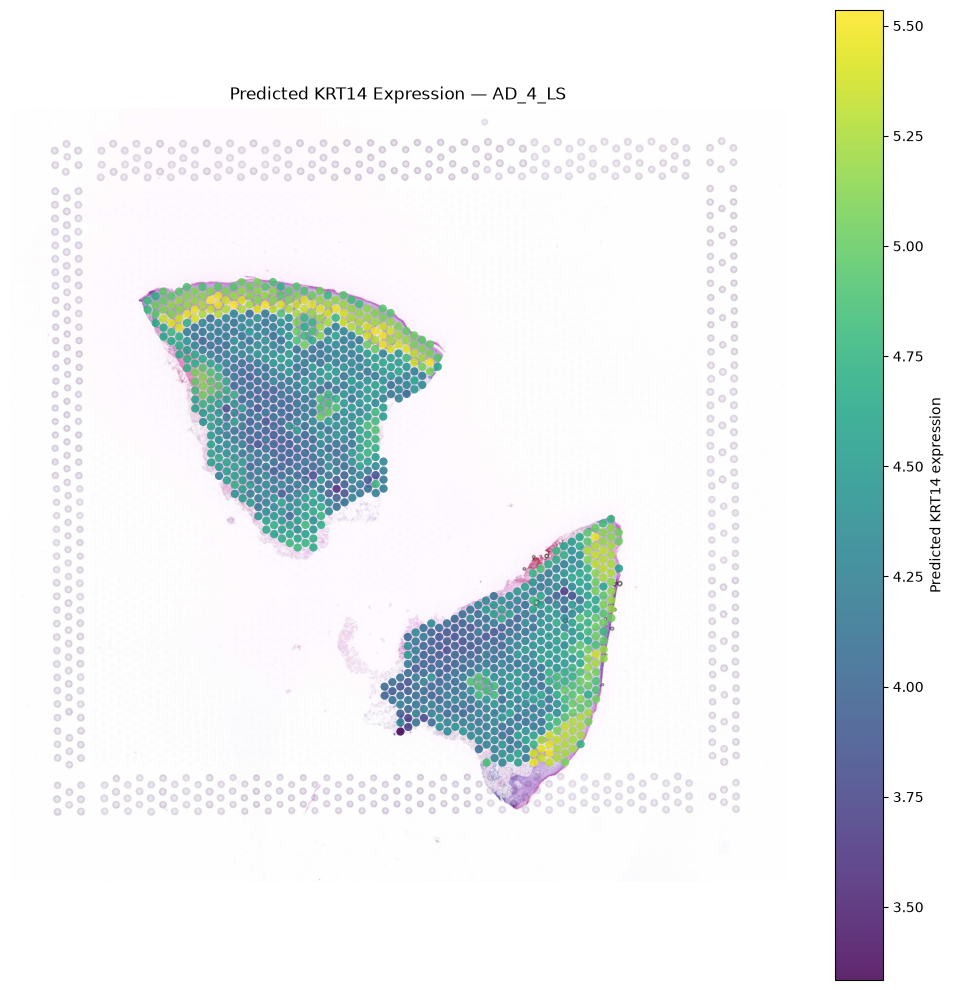

Saved: outputs/figures/AD_4_LS_KRT14_corrected_prediction.png
Spots plotted: 1177
X range: 354.4 – 1569.1
Y range: 448.7 – 1687.4


In [36]:
import matplotlib.pyplot as plt
import os

SAMPLE = "AD_4_LS"
GENE = "KRT14"

sample_data = datasets[SAMPLE]
adata = sample_data["adata"]
image = sample_data["image"]
positions = sample_data["positions"]

# Align positions to AnnData barcode order
positions_aligned = positions.loc[adata.obs_names].copy()

# Keep only spots inside tissue
tissue_mask = positions_aligned["in_tissue"] == 1
positions_aligned = positions_aligned[tissue_mask]

# Create matching unique IDs
unique_ids = [
    f"{SAMPLE}_{barcode}"
    for barcode in positions_aligned.index
]

# Select image features in matching order
sample_features = enhanced_image_features.loc[
    unique_ids,
    MODEL_FEATURES
]

# Train demonstration model
X_all = normalized_model_table[MODEL_FEATURES]
y_all = normalized_model_table[GENE]

final_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_all, y_all)

# Predict
predictions = final_model.predict(sample_features)

# Correct scaling factor
hires_scale = 0.102239035

x = positions_aligned["pixel_col"].to_numpy() * hires_scale
y = positions_aligned["pixel_row"].to_numpy() * hires_scale

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(image)

scatter = plt.scatter(
    x,
    y,
    c=predictions,
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolors="none"
)

plt.colorbar(scatter, label=f"Predicted {GENE} expression")
plt.title(f"Predicted {GENE} Expression — {SAMPLE}")
plt.axis("off")
plt.tight_layout()

# Save
os.makedirs("outputs/figures", exist_ok=True)

output_path = (
    f"outputs/figures/{SAMPLE}_{GENE}_corrected_prediction.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {output_path}")
print(f"Spots plotted: {len(predictions)}")
print(f"X range: {x.min():.1f} – {x.max():.1f}")
print(f"Y range: {y.min():.1f} – {y.max():.1f}")

In [37]:
SAMPLE = "AD_4_LS"

sample_data = datasets[SAMPLE]
image = sample_data["image"]
positions = sample_data["positions"]

# Convert PIL image to NumPy array
image_array = np.asarray(image)

print("Image size (width, height):", image.size)
print("Image shape (height, width, channels):", image_array.shape)

print("\nPosition columns:")
print(positions.columns.tolist())

print("\nCoordinate ranges:")
print(
    "pixel_row:",
    positions["pixel_row"].min(),
    positions["pixel_row"].max()
)

print(
    "pixel_col:",
    positions["pixel_col"].min(),
    positions["pixel_col"].max()
)

print("\nFirst 5 positions:")
display(positions.head())

print("\nDataset keys:")
print(sample_data.keys())

Image size (width, height): (2000, 1996)
Image shape (height, width, channels): (1996, 2000, 3)

Position columns:
['in_tissue', 'array_row', 'array_col', 'pixel_row', 'pixel_col']

Coordinate ranges:
pixel_row: 4389 16504
pixel_col: 3466 15347

First 5 positions:


,in_tissue,array_row,array_col,pixel_row,pixel_col
AAACACCAATAACTGC-1,1,59,19,14339,13780
AAACAGAGCGACTCCT-1,1,14,94,5872,4854
AAACAGCTTTCAGAAG-1,1,43,9,15489,10627
AAACAGGGTCTATATT-1,1,47,13,15032,11414
AAACCGGGTAGGTACC-1,1,42,28,13334,10419



Dataset keys:
dict_keys(['adata', 'image', 'positions'])


In [38]:
from pathlib import Path
import json

SAMPLE = "AD_4_LS"

current_path = Path.cwd()

print("Current working directory:")
print(current_path)

# Search current directory and parent directories
search_roots = [current_path] + list(current_path.parents)

scale_files = []

for root in search_roots:
    scale_files.extend(
        root.glob(
            f"data/processed/{SAMPLE}/**/spatial/scalefactors_json.json"
        )
    )

# Remove duplicates
scale_files = list(dict.fromkeys(scale_files))

print("\nFound files:")
for file in scale_files:
    print(file)

if scale_files:
    with open(scale_files[0], "r") as f:
        scalefactors = json.load(f)

    print("\nScalefactors:")
    print(json.dumps(scalefactors, indent=2))
else:
    print("\nFile not found. We will locate the project root next.")

Current working directory:
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\notebooks

Found files:
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\data\processed\AD_4_LS\AD_4_LS\spatial\scalefactors_json.json

Scalefactors:
{
  "spot_diameter_fullres": 147.51693999999998,
  "tissue_hires_scalef": 0.102239035,
  "fiducial_diameter_fullres": 238.29660000000007,
  "tissue_lowres_scalef": 0.03067171
}


C:\Users\Manya Aggarwal\AppData\Local\Temp\ipykernel_7416\3220003439.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


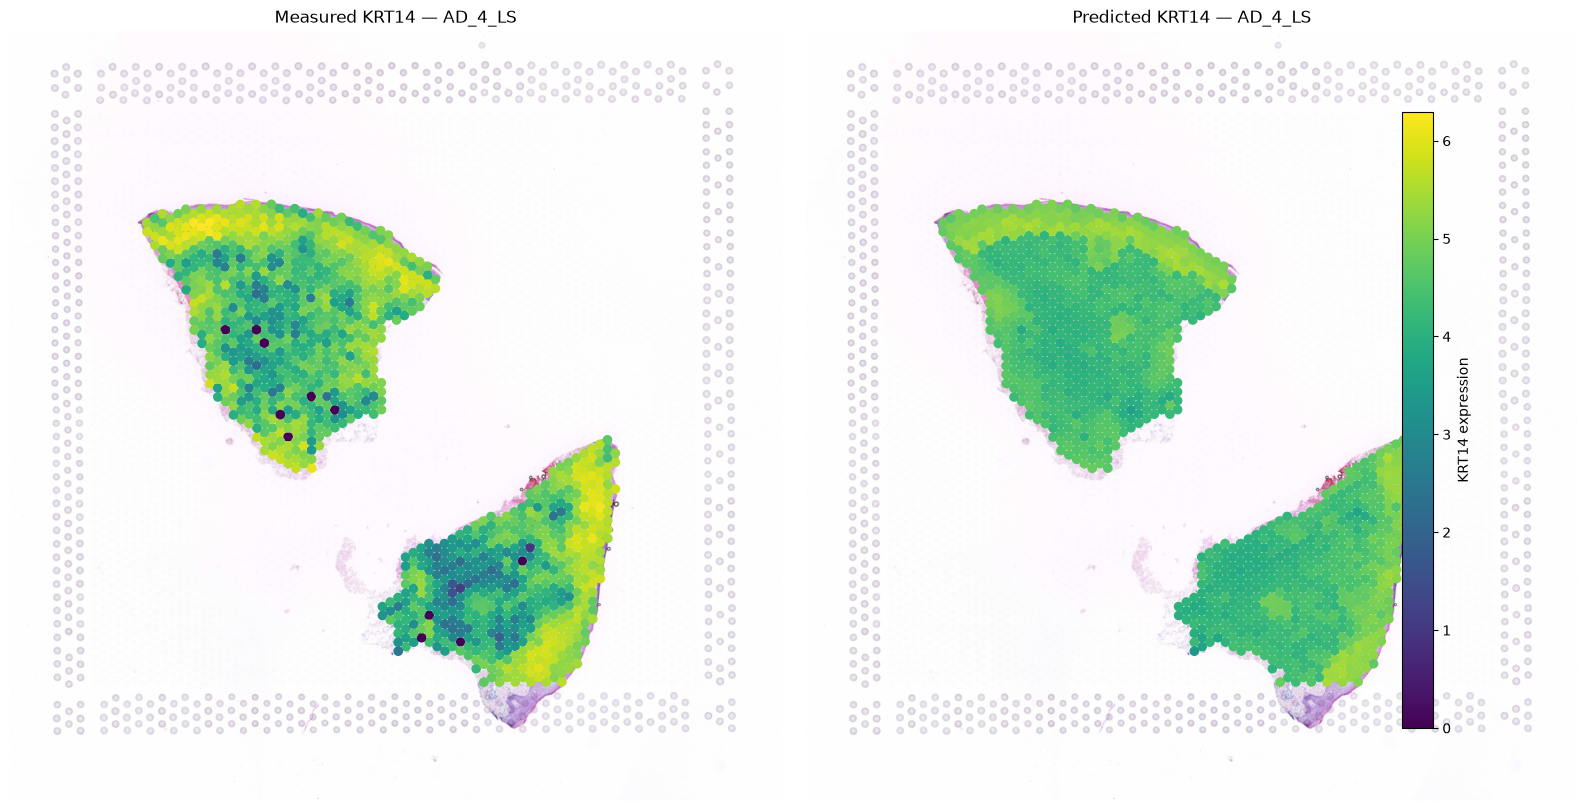

Saved: outputs/figures/AD_4_LS_KRT14_measured_vs_predicted.png


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import os

SAMPLE = "AD_4_LS"
GENE = "KRT14"

sample_data = datasets[SAMPLE]
image = sample_data["image"]
positions = sample_data["positions"]

# Align positions with AnnData barcodes
positions_aligned = positions.loc[adata.obs_names].copy()
positions_aligned = positions_aligned[
    positions_aligned["in_tissue"] == 1
]

unique_ids = [
    f"{SAMPLE}_{barcode}"
    for barcode in positions_aligned.index
]

# Image features
X_sample = enhanced_image_features.loc[
    unique_ids, MODEL_FEATURES
]

# Train model using all available samples
final_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    normalized_model_table[MODEL_FEATURES],
    normalized_model_table[GENE]
)

# Predictions
predicted_expression = final_model.predict(X_sample)

# Actual measured expression
actual_expression = normalized_expression_df.loc[
    unique_ids, GENE
].to_numpy()

# Coordinates
scale_factor = 0.102239035

x = positions_aligned["pixel_col"].to_numpy() * scale_factor
y = positions_aligned["pixel_row"].to_numpy() * scale_factor

# Shared color scale
vmin = min(actual_expression.min(), predicted_expression.min())
vmax = max(actual_expression.max(), predicted_expression.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Measured map
axes[0].imshow(image)
scatter_1 = axes[0].scatter(
    x, y,
    c=actual_expression,
    cmap="viridis",
    s=35,
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title(f"Measured {GENE} — {SAMPLE}")
axes[0].axis("off")

# Predicted map
axes[1].imshow(image)
scatter_2 = axes[1].scatter(
    x, y,
    c=predicted_expression,
    cmap="viridis",
    s=35,
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title(f"Predicted {GENE} — {SAMPLE}")
axes[1].axis("off")

fig.colorbar(
    scatter_2,
    ax=axes,
    fraction=0.025,
    pad=0.04,
    label=f"{GENE} expression"
)

plt.tight_layout()

os.makedirs("outputs/figures", exist_ok=True)

output_path = (
    f"outputs/figures/{SAMPLE}_{GENE}_measured_vs_predicted.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {output_path}")

In [40]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Quantitative comparison
pearson_corr, pearson_p = pearsonr(
    actual_expression,
    predicted_expression
)

spearman_corr, spearman_p = spearmanr(
    actual_expression,
    predicted_expression
)

mae = mean_absolute_error(
    actual_expression,
    predicted_expression
)

rmse = np.sqrt(mean_squared_error(
    actual_expression,
    predicted_expression
))

r2 = r2_score(
    actual_expression,
    predicted_expression
)

print(f"Gene: {GENE}")
print(f"Sample: {SAMPLE}")
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Gene: KRT14
Sample: AD_4_LS
Pearson correlation: 0.6500
Spearman correlation: 0.7078
MAE: 0.6049
RMSE: 0.8007
R²: 0.3619


In [41]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

SAMPLE = "AD_4_LS"
GENE = "KRT14"

# Split by sample
train_data = normalized_model_table[
    normalized_model_table["sample_id"] != SAMPLE
]

test_data = normalized_model_table[
    normalized_model_table["sample_id"] == SAMPLE
]

X_train = train_data[MODEL_FEATURES]
y_train = train_data[GENE]

X_test = test_data[MODEL_FEATURES]
y_test = test_data[GENE]

# Train only on the other samples
heldout_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

heldout_model.fit(X_train, y_train)

predictions = heldout_model.predict(X_test)

# Metrics
pearson_corr, _ = pearsonr(y_test, predictions)
spearman_corr, _ = spearmanr(y_test, predictions)

print(f"Gene: {GENE}")
print(f"Held-out sample: {SAMPLE}")
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.4f}")
print(f"R²: {r2_score(y_test, predictions):.4f}")

Gene: KRT14
Held-out sample: AD_4_LS
Pearson correlation: 0.0548
Spearman correlation: 0.0558
MAE: 0.8268
RMSE: 1.0617
R²: -0.1217


In [42]:
# Compare normalized models against a mean baseline
# using leave-one-sample-out evaluation.

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

comparison_results = []

for test_sample in SAMPLE_IDS:

    train_data = normalized_model_table[
        normalized_model_table["sample_id"] != test_sample
    ]

    test_data = normalized_model_table[
        normalized_model_table["sample_id"] == test_sample
    ]

    X_train = train_data[MODEL_FEATURES]
    X_test = test_data[MODEL_FEATURES]

    for gene in valid_genes:

        y_train = train_data[gene]
        y_test = test_data[gene]

        # Mean baseline
        baseline_predictions = np.full(
            len(y_test),
            y_train.mean()
        )

        comparison_results.append({
            "test_sample": test_sample,
            "gene": gene,
            "model": "MeanBaseline",
            "MAE": mean_absolute_error(
                y_test, baseline_predictions
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test, baseline_predictions
                )
            ),
            "R2": r2_score(
                y_test, baseline_predictions
            )
        })

        # ML models
        for model_name, model in models.items():

            model.fit(X_train, y_train)
            predictions = model.predict(X_test)

            comparison_results.append({
                "test_sample": test_sample,
                "gene": gene,
                "model": model_name,
                "MAE": mean_absolute_error(
                    y_test, predictions
                ),
                "RMSE": np.sqrt(
                    mean_squared_error(y_test, predictions)
                ),
                "R2": r2_score(y_test, predictions)
            })

complete_comparison_df = pd.DataFrame(comparison_results)

complete_summary_df = (
    complete_comparison_df
    .groupby(["gene", "model"])[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
    .round(4)
)

display(complete_summary_df)

# Save results
import os

os.makedirs("outputs/results", exist_ok=True)

complete_comparison_df.to_csv(
    "outputs/results/normalized_complete_comparison.csv",
    index=False
)

complete_summary_df.to_csv(
    "outputs/results/normalized_complete_summary.csv",
    index=False
)

print("Saved complete baseline comparison.")

,gene,model,MAE,RMSE,R2
0,FLG,ExtraTrees,1.0044,1.1658,-0.5101
1,FLG,MeanBaseline,0.9277,1.1245,-0.3772
2,FLG,RandomForest,1.0108,1.1723,-0.5148
3,FLG,Ridge,0.9789,1.1649,-0.4840
4,IL13,ExtraTrees,0.0128,0.0737,-0.0154
5,IL13,MeanBaseline,0.0118,0.0726,-0.0023
6,IL13,RandomForest,0.0183,0.0768,-0.1137
7,IL13,Ridge,0.0144,0.0730,-0.0172
8,KRT10,ExtraTrees,0.9136,1.1695,-2.4938
9,KRT10,MeanBaseline,0.9950,1.2009,-2.5575


Saved complete baseline comparison.
